In [3]:
import numpy as np
from metloom.pointdata import SnotelPointData
import pandas as pd
from datetime import datetime

In [4]:
# pip install metloom

In [5]:
snotel_point = SnotelPointData("637:ID:SNTL", "MCS") # define the snotel ID

# get the daily data for the snotel site for the specified date range and variables
df = snotel_point.get_daily_data(
    datetime(2024, 11, 1), datetime(2024, 12, 5),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

df["SNOWDEPTH (m)"] = df["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
df.to_csv("snotel_data.csv", index=False) # save the data to a csv file

df

,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource,SNOWDEPTH (m)
datetime,site,,,,,
2024-11-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6100.00000),4.0,in,NRCS,0.1016
2024-11-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6100.00000),4.0,in,NRCS,0.1016
2024-11-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6100.00000),6.0,in,NRCS,0.1524
2024-11-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6100.00000),6.0,in,NRCS,0.1524
2024-11-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6100.00000),8.0,in,NRCS,0.2032
2024-11-06 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6100.00000),8.0,in,NRCS,0.2032
2024-11-07 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6100.00000),7.0,in,NRCS,0.1778
2024-11-08 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6100.00000),7.0,in,NRCS,0.1778
2024-11-09 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6100.00000),7.0,in,NRCS,0.1778


In [6]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 35 entries, (Timestamp('2024-11-01 08:00:00+0000', tz='UTC'), '637:ID:SNTL') to (Timestamp('2024-12-05 08:00:00+0000', tz='UTC'), '637:ID:SNTL')
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   geometry         35 non-null     geometry
 1   SNOWDEPTH        35 non-null     float64 
 2   SNOWDEPTH_units  35 non-null     object  
 3   datasource       35 non-null     object  
 4   SNOWDEPTH (m)    35 non-null     float64 
dtypes: float64(2), geometry(1), object(2)
memory usage: 3.0+ KB


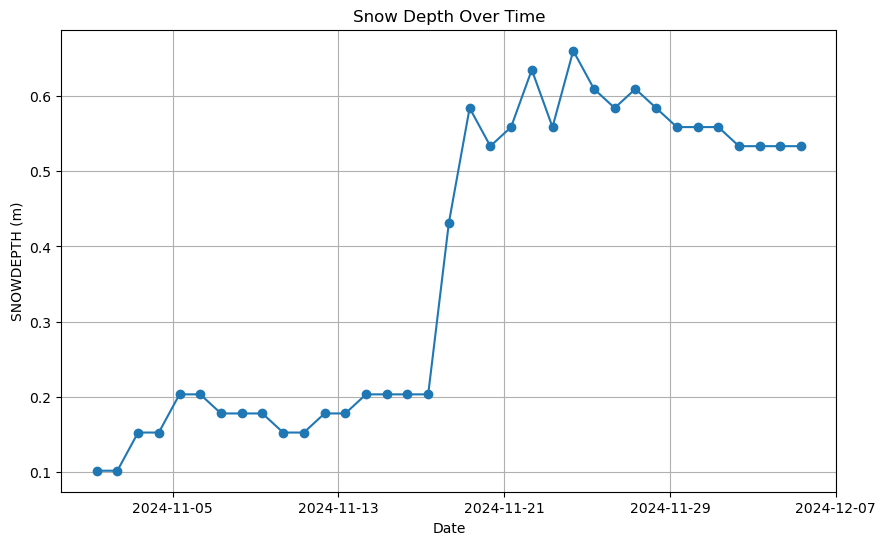

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Extract the datetime index and SNOWDEPTH (m) values
dates = df.index.get_level_values(0)
snowdepth = df['SNOWDEPTH (m)']

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dates, snowdepth, marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('SNOWDEPTH (m)')
plt.title('Snow Depth Over Time')
plt.grid(True)

# Format the x-axis to show only 5 labels
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))

plt.show()